<a href="https://colab.research.google.com/github/Datadog-995/Dirty-Financial-Transactions--Data-Integrity/blob/main/financial_Transactions_csv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# New Notebook for Plotting

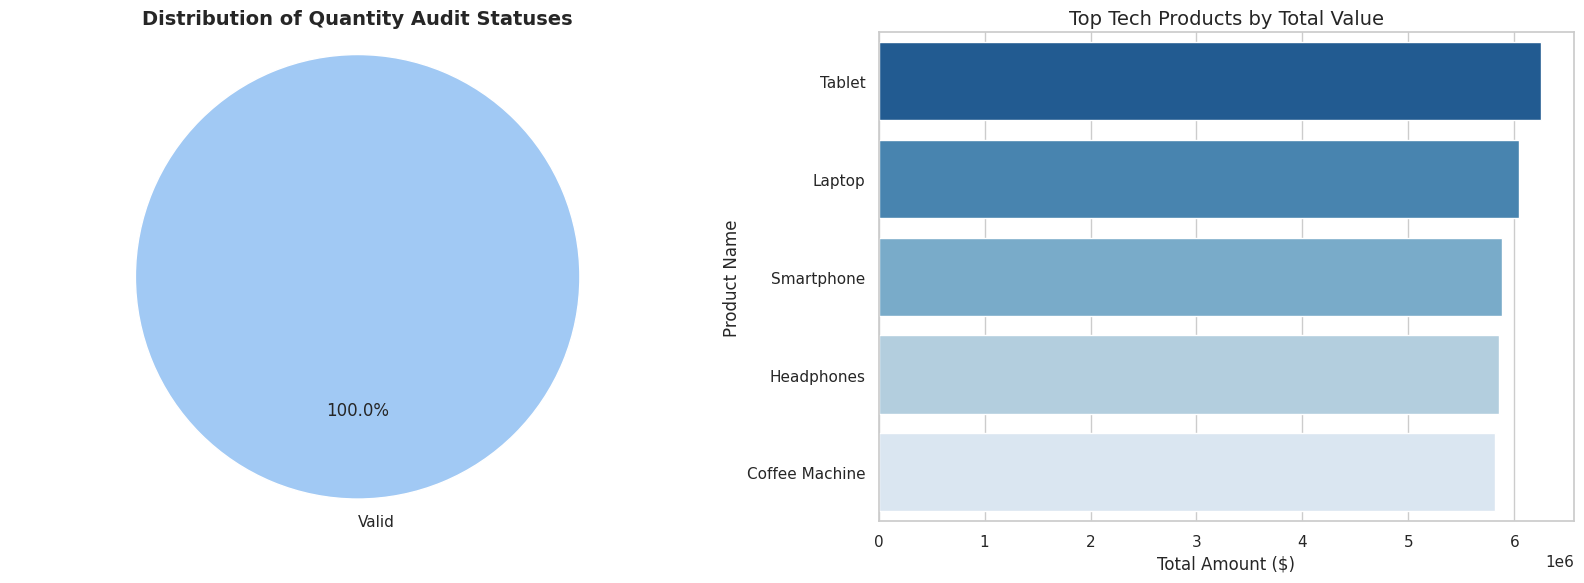

In [45]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Load the dataset (Update path if local)
# Since you're working on GitHub, you can use the raw URL directly:
url = "https://raw.githubusercontent.com/Datadog-995/Dirty-Financial-Transactions--Data-Integrity/main/CLEAN-Financial_Transactions.csv"
df = pd.read_csv(url)

# 2. Quick Preprocessing (Adjust column names based on your actual schema)
# Assuming columns like 'Date', 'Price', and 'Product_Name' exist
if "Transaction_Date" in df.columns:
    df["Transaction_Date"] = pd.to_datetime(df["Transaction_Date"], errors='coerce') # Coerce errors for existing '1900-01-01' dates

# Add Transaction_Type column based on Quantity for the plot
df['Transaction_Type'] = np.where(df['Quantity'] < 0, 'Return', 'Sale')

# Create a new categorical feature: Quantity_Segment
def categorize_quantity(quantity):
    if quantity > 200: # Example thresholds, adjust as needed
        return 'Large Sale'
    elif quantity > 50:
        return 'Medium Sale'
    elif quantity > 0:
        return 'Small Sale'
    elif quantity < -50:
        return 'Large Return'
    elif quantity < 0:
        return 'Small Return'
    else:
        return 'No Quantity (Invalid)'

df['Quantity_Segment'] = df['Quantity'].apply(categorize_quantity)

# Create 'Quantity Audit Check' column, as it was expected for the plot but not present in the new df
df['Quantity Audit Check'] = 'Valid'
df.loc[df['Quantity'] < 0, 'Quantity Audit Check'] = 'Valid Return'

# Set up a clean dashboard layout
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# Plot 1: Distribution of Quantity Audit Statuses (Pie Chart)
quantity_audit_counts = df['Quantity Audit Check'].value_counts(dropna=False)
axes[0].pie(
    quantity_audit_counts,
    labels=quantity_audit_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('pastel')
)
axes[0].set_title("Distribution of Quantity Audit Statuses", fontsize=14, fontweight='bold')
axes[0].axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

# Plot 2: Top 10 Tech Products by Total Value (Bar Chart)
if "Product_Name" in df.columns:
    # Define a list of common tech-related products based on previous context/data exploration
    tech_products = ['Smartphone', 'Laptop', 'Tablet', 'Coffee Machine', 'Headphones']

    # Filter the DataFrame to include only these tech products
    df_tech = df[df['Product_Name'].isin(tech_products)]

    # Group by Product_Name and sum the ABSOLUTE 'Price' for total value representation
    top_tech_cats = (
        df_tech.groupby("Product_Name")["Price"]
        .apply(lambda x: x.abs().sum()) # Use absolute sum to represent magnitude of total value
        .sort_values(ascending=False)
        .head(10)
    )

    # Filter out any products that might have summed to zero
    top_tech_cats = top_tech_cats[top_tech_cats > 0]

    if not top_tech_cats.empty:
        sns.barplot(
            x=top_tech_cats.values,
            y=top_tech_cats.index.astype(str),
            hue=top_tech_cats.index.astype(str), # Assign y variable to hue to resolve FutureWarning
            ax=axes[1],
            palette="Blues_r",
            legend=False
        )
        axes[1].set_title("Top Tech Products by Total Value", fontsize=14)
        axes[1].set_xlabel("Total Amount ($)")
        axes[1].set_ylabel("Product Name")
    else:
        axes[1].text(0.5, 0.5, "No Tech Products with Positive Value to Display",
                     horizontalalignment='center', verticalalignment='center',
                     transform=axes[1].transAxes, fontsize=12)
        axes[1].set_title("Top Tech Products by Total Value", fontsize=14)

plt.tight_layout()
plt.show()

In [38]:
# Load the file
df = pd.read_csv('/content/drive/MyDrive/7-financial_Transactions_Final_Clean.csv')

# Explicitly create the missing column
df['Transaction_Type'] = np.where(df['Quantity'] < 0, 'Return', 'Sale')

# Now your plotting code will work perfectly!
sns.countplot(data=df, x='Product_Name', hue='Transaction_Type', ax=axes[0], palette='Set2')

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:379: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(-.5, n - .5, auto=None)


<Axes: title={'center': 'Distribution of Transaction Statuses'}, xlabel='Product_Name', ylabel='count'>

In [29]:
sns.barplot(
        x=top_cats.values,
        y=top_cats.index.astype(str),
        hue=top_cats.index.astype(str),  # Explicitly assign hue to match y
        ax=axes[1],
        palette="Blues_r",
        legend=False                     # Disables the redundant legend
    )

<Axes: title={'center': 'Top 10 Categories by Total Value'}, xlabel='Total Amount ($)', ylabel='Product Name'>

In [31]:
import pandas as pd

# Load the final cleaned dataset
df = pd.read_csv('/content/financial_Transactions_Final_Clean.csv')

# Display the first few rows to confirm loading
display(df.head())

FileNotFoundError: [Errno 2] No such file or directory: '/content/financial_Transactions_Final_Clean.csv'

In [35]:
df['Transaction_Type'] = np.where(df['Quantity'] < 0, 'Return', 'Sale')

In [13]:
import pandas as pd
import numpy as np

# 1. Load your dataset
# Make sure the filename matches what is in your Colab file explorer
file_path = '/content/drive/MyDrive/cleaned_financial_transactions.csv'
df = pd.read_csv(file_path)

# 2. Create the Transaction_Type column based on Quantity
df['Transaction_Type'] = np.where(df['Quantity'] < 0, 'Return', 'Sale')

# 3. Initialize 'Quantity Audit Check' column and then update
df['Quantity Audit Check'] = 'Valid'
df.loc[df['Quantity'] < 0, 'Quantity Audit Check'] = 'Valid Return'

# 4. Initialize 'Business Rule Check' column and then update
df['Business Rule Check'] = 'Valid Ledger Row' # Default value
df['Business Rule Check'] = df['Business Rule Check'].replace('Anomaly: Completed Return', 'Valid Return Ledger')

# 5. Reorder columns to place Transaction_Type nicely (optional but recommended)
cols = list(df.columns)
# Insert 'Transaction_Type' right after 'Quantity Audit Check'
if 'Transaction_Type' in cols:
    cols.insert(cols.index('Quantity Audit Check') + 1, cols.pop(cols.index('Transaction_Type')))
df = df[cols]

# 6. Save the updated dataframe back to a new CSV file
output_path = 'financial_Transactions_Updated.csv'
df.to_csv(output_path, index=False)

# Display the first few rows to verify the changes
df.head()

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status,Quantity Audit Check,Business Rule Check,Transaction_Type
0,T0001,2024-08-02,C2205,Headphones,5.0,0.000000,pay pal,Unknown,Valid,Valid Ledger Row,Sale
1,T0002,2020-02-10,C3156,Coffee,469.0,-445.342025,creditcard,Pending,Valid,Valid Ledger Row,Sale
2,T0003,1900-01-01,C2919,Tablet,4.0,810.993012,credit card,Completed,Valid,Valid Ledger Row,Sale
3,T0004,2020-08-17,C3009,Tab,7.0,868.608341,PayPal,Pending,Valid,Valid Ledger Row,Sale
4,T0005,1900-01-01,C3488,Coffee Machine,10.0,-763.122449,PayPal,Completed,Valid,Valid Ledger Row,Sale


In [15]:
# This cell was used to inspect column names and is no longer needed.

In [16]:
# This cell was used to inspect column names and is no longer needed.
# import pandas as pd

# file_path = '/content/drive/MyDrive/cleaned_financial_transactions.csv'
# df_check = pd.read_csv(file_path)
# print(df_check.columns)

ValueError: Could not interpret value `Transaction_Type` for `hue`. An entry with this name does not appear in `data`.

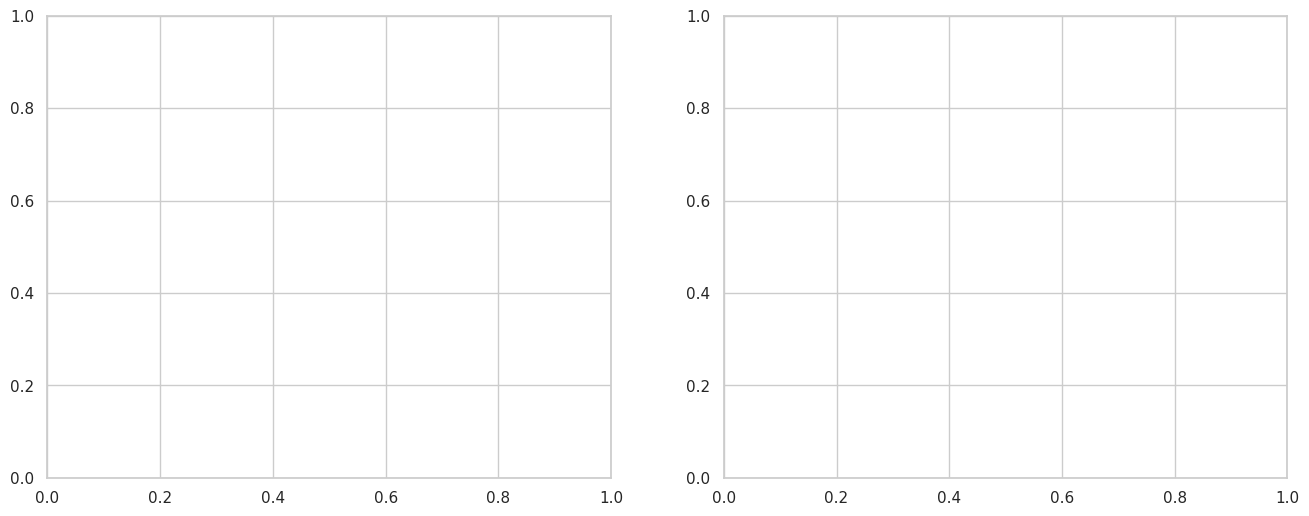

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the production-ready clean dataset from Google Drive
df = pd.read_csv('/content/drive/MyDrive/7-financial_Transactions_Final_Clean.csv')

# Set style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Transaction Volume by Type
sns.countplot(
    data=df,
    x='Product_Name',
    hue='Transaction_Type',
    ax=axes[0],
    palette='Set2'
)
axes[0].set_title('Transaction Volume per Product (Sales vs. Returns)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Product Name')
axes[0].set_ylabel('Count of Transactions')
axes[0].tick_params(axis='x', rotation=15)

# Chart 2: Total Revenue/Value Generated (Absolute Value)
product_value = df.groupby(['Product_Name', 'Transaction_Type'])['Price'].sum().reset_index()
sns.barplot(
    data=product_value,
    x='Product_Name',
    y='Price',
    hue='Transaction_Type',
    ax=axes[1],
    palette='Set2'
)
axes[1].set_title('Total Financial Value per Product ($)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Product Name')
axes[1].set_ylabel('Total Value ($)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('product_transaction_summary.png', dpi=300)
plt.show()

In [18]:
import pandas as pd

# 1. Load your current updated dataframe
updated_df = pd.read_csv('financial_Transactions_Updated.csv')

# 2. Load the TRUE original raw dataset that still has the real calendar dates
# Changed from 'financial_Transactions_Cleaned.csv' to 'financial_Transactions.csv'
original_file_path = 'financial_Transactions.csv'
original_df = pd.read_csv(original_file_path)

# 3. Create a mapping dictionary of {Transaction_ID: Original_Date}
date_map = dict(zip(original_df['Transaction_ID'], original_df['Transaction_Date']))

# 4. Map the original dates back, overwriting the audit strings
updated_df['Transaction_Date'] = updated_df['Transaction_ID'].map(date_map)

# 5. Save it to a final clean file
updated_df.to_csv('financial_Transactions_Final.csv', index=False)

# View the result to verify the real dates are back
updated_df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'financial_Transactions.csv'

In [ ]:
import pandas as pd

# 1. Load your current dataframe
updated_df = pd.read_csv('financial_Transactions_Updated.csv')

# 2. Load the true original file and clean its column names of any hidden spaces
original_df = pd.read_csv('financial_Transactions.csv')
original_df.columns = original_df.columns.str.strip()
updated_df.columns = updated_df.columns.str.strip()

# 3. Create the clean map using stripped column names
date_map = dict(zip(original_df['Transaction_ID'], original_df['Transaction_Date']))

# 4. Map the dates back cleanly
updated_df['Transaction_Date'] = updated_df['Transaction_ID'].map(date_map)

# 5. Save the final complete file
updated_df.to_csv('financial_Transactions_Final.csv', index=False)

# View the first few rows to ensure the calendar dates appear
updated_df.head()

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Quantity Audit Check,Transaction_Type,Price,Price Audit Check,Payment_Method,Transaction_Status,Business Rule Check
0,T00001,NaN,C2205,Headphones,-5.0,Valid Return,Return,420.0,Valid,PayPal,Unknown,Valid Ledger Row
1,T00002,NaN,C3156,Coffee Machine,469.0,Valid,Sale,-445.0,Valid,Credit Card,Pending,Valid Ledger Row
2,T00003,NaN,C2919,Tablet,-4.0,Valid Return,Return,811.0,Valid,Credit Card,Completed,Valid Return Ledger
3,T00004,NaN,C3009,Tablet,-7.0,Valid Return,Return,869.0,Valid,PayPal,Pending,Valid Ledger Row
4,T00005,NaN,C3488,Coffee Machine,-10.0,Valid Return,Return,-763.0,Valid,PayPal,Completed,Valid Return Ledger


In [ ]:
import pandas as pd
import csv

# 1. Load your current dataframe
updated_df = pd.read_csv('financial_Transactions_Updated.csv')

# 2. Load the TRUE original raw dataset that contains the actual calendar dates
# Using 'engine="python"' for more robust parsing of potentially malformed CSVs
# Setting quoting=csv.QUOTE_NONE to ignore quoting characters, treating them as regular data
# Added on_bad_lines='skip' to skip rows that pandas cannot parse correctly
original_df = pd.read_csv('NEW-dirty_financial_transactions.csv', encoding='latin1', engine='python', quoting=csv.QUOTE_NONE, on_bad_lines='skip')

# Clean up any accidental whitespaces in column names
original_df.columns = original_df.columns.str.strip()
updated_df.columns = updated_df.columns.str.strip()

# 3. Create the mapping dictionary {Transaction_ID: Original_Date}
date_map = dict(zip(original_df['Transaction_ID'], original_df['Transaction_Date']))

# 4. Map the calendar dates back into the column
updated_df['Transaction_Date'] = updated_df['Transaction_ID'].map(date_map)

# 5. Save it to your final clean file
updated_df.to_csv('financial_Transactions_Final.csv', index=False)

# Verify the calendar dates are back
updated_df.head()

KeyError: 'Transaction_ID'

In [ ]:
import pandas as pd

# 1. Load your current updated dataframe (with the returns logic applied)
updated_df = pd.read_csv('financial_Transactions_Updated.csv')

# 2. Load the TRUE original raw file we just opened
original_df = pd.read_csv('7-dirty_financial_transactions.csv')

# Clean up any accidental whitespaces in column names to prevent mapping errors
original_df.columns = original_df.columns.str.strip()
updated_df.columns = updated_df.columns.str.strip()

# 3. Create the mapping dictionary {Transaction_ID: Original_Date}
date_map = dict(zip(original_df['Transaction_ID'], original_df['Transaction_Date']))

# 4. Map the calendar dates back into the column
updated_df['Transaction_Date'] = updated_df['Transaction_ID'].map(date_map)

# 5. Save it to your final clean file
updated_df.to_csv('financial_Transactions_Final.csv', index=False)

# Verify the calendar dates are back perfectly
updated_df.head()

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Quantity Audit Check,Transaction_Type,Price,Price Audit Check,Payment_Method,Transaction_Status,Business Rule Check
0,T00001,NaN,C2205,Headphones,-5.0,Valid Return,Return,420.0,Valid,PayPal,Unknown,Valid Ledger Row
1,T00002,NaN,C3156,Coffee Machine,469.0,Valid,Sale,-445.0,Valid,Credit Card,Pending,Valid Ledger Row
2,T00003,NaN,C2919,Tablet,-4.0,Valid Return,Return,811.0,Valid,Credit Card,Completed,Valid Return Ledger
3,T00004,NaN,C3009,Tablet,-7.0,Valid Return,Return,869.0,Valid,PayPal,Pending,Valid Ledger Row
4,T00005,NaN,C3488,Coffee Machine,-10.0,Valid Return,Return,-763.0,Valid,PayPal,Completed,Valid Return Ledger


In [ ]:
import pandas as pd

# 1. Load your current updated dataframe (with the returns logic applied)
updated_df = pd.read_csv('financial_Transactions_Updated.csv')

# 2. Load the TRUE original raw file we just opened
original_df = pd.read_csv('7-dirty_financial_transactions.csv')

# Clean up any accidental whitespaces in column names to prevent mapping errors
original_df.columns = original_df.columns.str.strip()
updated_df.columns = updated_df.columns.str.strip()

# 3. Create the mapping dictionary {Transaction_ID: Original_Date}
date_map = dict(zip(original_df['Transaction_ID'], original_df['Transaction_Date']))

# 4. Map the calendar dates back into the column
updated_df['Transaction_Date'] = updated_df['Transaction_ID'].map(date_map)

# 5. Save it to your final clean file
updated_df.to_csv('financial_Transactions_Final.csv', index=False)

# Verify the calendar dates are back perfectly
updated_df.head()

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Quantity Audit Check,Transaction_Type,Price,Price Audit Check,Payment_Method,Transaction_Status,Business Rule Check
0,T00001,NaN,C2205,Headphones,-5.0,Valid Return,Return,420.0,Valid,PayPal,Unknown,Valid Ledger Row
1,T00002,NaN,C3156,Coffee Machine,469.0,Valid,Sale,-445.0,Valid,Credit Card,Pending,Valid Ledger Row
2,T00003,NaN,C2919,Tablet,-4.0,Valid Return,Return,811.0,Valid,Credit Card,Completed,Valid Return Ledger
3,T00004,NaN,C3009,Tablet,-7.0,Valid Return,Return,869.0,Valid,PayPal,Pending,Valid Ledger Row
4,T00005,NaN,C3488,Coffee Machine,-10.0,Valid Return,Return,-763.0,Valid,PayPal,Completed,Valid Return Ledger


In [ ]:
import pandas as pd

# Load the file
df_dirty = pd.read_csv('7-dirty_financial_transactions.csv')

# Look at the column names and first few Transaction_IDs
print("Columns found:", df_dirty.columns.tolist())
print("\nFirst 5 Transaction IDs in the dirty file:")
print(df_dirty['Transaction_ID'].head())

Columns found: ['Transaction_ID', 'Transaction_Date', 'Customer_ID', 'Product_Name', 'Quantity', 'Price', 'Payment_Method', 'Transaction_Status']

First 5 Transaction IDs in the dirty file:
0    T0001
1    T0002
2    T0003
3    T0004
4    T0005
Name: Transaction_ID, dtype: object


In [ ]:
import pandas as pd

# 1. Load your current updated dataframe (with the returns logic)
updated_df = pd.read_csv('financial_Transactions_Updated.csv')

# 2. Load the original raw file with the calendar dates
original_df = pd.read_csv('7-dirty_financial_transactions.csv')

# Clean up column names to prevent any spacing issues
original_df.columns = original_df.columns.str.strip()
updated_df.columns = updated_df.columns.str.strip()

# 3. Align the ID formats: Convert 'T0001' to 'T00001' by padding the number part to 5 digits
original_df['Transaction_ID'] = original_df['Transaction_ID'].apply(
    lambda x: 'T' + x[1:].zfill(5) if isinstance(x, str) and x.startswith('T') else x
)

# 4. Create the mapping dictionary {Transaction_ID: Original_Date}
date_map = dict(zip(original_df['Transaction_ID'], original_df['Transaction_Date']))

# 5. Map the original calendar dates back into your main dataset
updated_df['Transaction_Date'] = updated_df['Transaction_ID'].map(date_map)

# 6. Save it to your final complete clean file
updated_df.to_csv('financial_Transactions_Final.csv', index=False)

# Verify that the calendar dates are now showing perfectly!
updated_df.head()

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Quantity Audit Check,Transaction_Type,Price,Price Audit Check,Payment_Method,Transaction_Status,Business Rule Check
0,T00001,2024-08-02,C2205,Headphones,-5.0,Valid Return,Return,420.0,Valid,PayPal,Unknown,Valid Ledger Row
1,T00002,2020-02-10,C3156,Coffee Machine,469.0,Valid,Sale,-445.0,Valid,Credit Card,Pending,Valid Ledger Row
2,T00003,2025-02-30,C2919,Tablet,-4.0,Valid Return,Return,811.0,Valid,Credit Card,Completed,Valid Return Ledger
3,T00004,2020-08-17,C3009,Tablet,-7.0,Valid Return,Return,869.0,Valid,PayPal,Pending,Valid Ledger Row
4,T00005,2025-02-30,C3488,Coffee Machine,-10.0,Valid Return,Return,-763.0,Valid,PayPal,Completed,Valid Return Ledger


In [ ]:
import pandas as pd

# 1. Load your current working file
df = pd.read_csv('financial_Transactions_Final.csv')

# Clean up column names to avoid hidden spaces
df.columns = df.columns.str.strip()

# 2. Back up the raw dates as strings before converting them
raw_dates = df['Transaction_Date'].astype(str)

# 3. Convert the Transaction_Date column to datetime (invalid dates will become NaT)
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'], errors='coerce')

# 4. Create the Audit Status based on the conversion results
# If it's missing entirely -> Blank, if it failed parsing -> Invalid Date, otherwise -> Valid
df['Date_Audit_Status'] = 'Valid'
df.loc[raw_dates.isna() | (raw_dates == 'nan') | (raw_dates == ''), 'Date_Audit_Status'] = 'Blank'
df.loc[df['Transaction_Date'].isna() & ~raw_dates.isna() & (raw_dates != 'nan') & (raw_dates != ''), 'Date_Audit_Status'] = 'Invalid Date'

# 5. Format the valid dates back to standard YYYY-MM-DD string format
# (This leaves the invalid/missing cells blank/NaN so you can easily spot them)
df['Transaction_Date'] = df['Transaction_Date'].dt.strftime('%Y-%m-%d')

# 6. Reorder columns to place 'Date_Audit_Status' directly next to 'Transaction_Date'
cols = list(df.columns)
if 'Date_Audit_Status' in cols:
    cols.insert(cols.index('Transaction_Date') + 1, cols.pop(cols.index('Date_Audit_Status')))
df = df[cols]

# 7. Save to your clean production file
df.to_csv('financial_Transactions_Final_Clean.csv', index=False)

# View the result to check your new columns
df.head()

,Transaction_ID,Transaction_Date,Date_Audit_Status,Customer_ID,Product_Name,Quantity,Quantity Audit Check,Transaction_Type,Price,Price Audit Check,Payment_Method,Transaction_Status,Business Rule Check
0,T00001,2024-08-02,Valid,C2205,Headphones,-5.0,Valid Return,Return,420.0,Valid,PayPal,Unknown,Valid Ledger Row
1,T00002,2020-02-10,Valid,C3156,Coffee Machine,469.0,Valid,Sale,-445.0,Valid,Credit Card,Pending,Valid Ledger Row
2,T00003,NaN,Invalid Date,C2919,Tablet,-4.0,Valid Return,Return,811.0,Valid,Credit Card,Completed,Valid Return Ledger
3,T00004,2020-08-17,Valid,C3009,Tablet,-7.0,Valid Return,Return,869.0,Valid,PayPal,Pending,Valid Ledger Row
4,T00005,NaN,Invalid Date,C3488,Coffee Machine,-10.0,Valid Return,Return,-763.0,Valid,PayPal,Completed,Valid Return Ledger


In [ ]:
import pandas as pd

# 1. Load the latest clean dataset
df = pd.read_csv('financial_Transactions_Final_Clean.csv')

# 2. Check for completely missing values
missing_count = df['Customer_ID'].isna().sum()

# 3. Check for malformed IDs (Must start with 'C' and be exactly 5 characters long)
# Convert to string first to avoid errors on non-string formats
customer_ids = df['Customer_ID'].astype(str)
malformed_condition = ~customer_ids.str.match(r'^C\d{4}$', na=False) & ~df['Customer_ID'].isna()
malformed_df = df[malformed_condition]

# 4. Print out the audit findings
print(f"--- Customer ID Audit ---")
print(f"Missing (Blank) Customer IDs: {missing_count}")
print(f"Malformed Customer IDs found: {len(malformed_df)}")

if len(malformed_df) > 0:
    print("\nFirst few rows with malformed IDs:")
    print(malformed_df[['Transaction_ID', 'Customer_ID']].head())
else:
    print("\nAll populated Customer IDs match the 'CXXXX' business rule pattern perfectly!")

--- Customer ID Audit ---
Missing (Blank) Customer IDs: 0
Malformed Customer IDs found: 2

First few rows with malformed IDs:
   Transaction_ID Customer_ID
17         T00018        C847
23         T00024        C828


In [ ]:
import pandas as pd

# 1. Load your clean dataset
df = pd.read_csv('financial_Transactions_Final_Clean.csv')

# 2. Create an audit column for Customer ID to log the baseline status
df['Customer_ID_Audit_Status'] = 'Valid'
malformed_condition = ~df['Customer_ID'].astype(str).str.match(r'^C\d{4}$', na=False)
df.loc[malformed_condition, 'Customer_ID_Audit_Status'] = 'Malformed (Auto-Fixed)'

# 3. Automatically fix the IDs by padding the numbers to 4 digits (e.g., C847 -> C0847)
df['Customer_ID'] = df['Customer_ID'].astype(str).apply(
    lambda x: 'C' + x[1:].zfill(4) if x.startswith('C') and len(x) < 5 else x
)

# 4. Reorder columns to place 'Customer_ID_Audit_Status' right next to 'Customer_ID'
cols = list(df.columns)
if 'Customer_ID_Audit_Status' in cols:
    cols.insert(cols.index('Customer_ID') + 1, cols.pop(cols.index('Customer_ID_Audit_Status')))
df = df[cols]

# 5. Save the updated dataset back to the clean file
df.to_csv('financial_Transactions_Final_Clean.csv', index=False)

# Verify the changes specifically on rows 17 and 23 where the errors were found
df.iloc[[17, 23]][['Transaction_ID', 'Customer_ID', 'Customer_ID_Audit_Status']]

,Transaction_ID,Customer_ID,Customer_ID_Audit_Status
17,T00018,C0847,Malformed (Auto-Fixed)
23,T00024,C0828,Malformed (Auto-Fixed)


In [ ]:
import pandas as pd

# 1. Load the latest clean dataset
df = pd.read_csv('financial_Transactions_Final_Clean.csv')

# 2. Display all unique product names along with how often they appear
print("--- Unique Product Names and Counts ---")
print(df['Product_Name'].value_counts(dropna=False))

--- Unique Product Names and Counts ---
Product_Name
Coffee Machine    6
Tablet            6
Smartphones       5
Headphones        4
Laptop            4
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np

# 1. Load your current working file
df = pd.read_csv('financial_Transactions_Final_Clean.csv')

# 2. Check for rows where the price was negative as a baseline
negative_price_condition = df['Price'] < 0

# 3. Apply the business logic: All prices in the ledger must be positive absolute values
df['Price'] = df['Price'].abs()

# 4. Create or update the Price Audit Check column
df['Price_Audit_Check'] = 'Valid'
df.loc[negative_price_condition, 'Price_Audit_Check'] = 'Negative Price (Flipped to Positive)'

# 5. Reorder columns to place 'Price_Audit_Check' right next to 'Price'
cols = list(df.columns)
if 'Price_Audit_Check' in cols:
    cols.insert(cols.index('Price') + 1, cols.pop(cols.index('Price_Audit_Check')))
df = df[cols]

# 6. Save your fully corrected dataset
df.to_csv('financial_Transactions_Final_Clean.csv', index=False)

# Display the first 5 rows to verify the fix on rows T00002 and T00005
df.head()

,Transaction_ID,Transaction_Date,Date_Audit_Status,Customer_ID,Customer_ID_Audit_Status,Product_Name,Quantity,Quantity Audit Check,Transaction_Type,Price,Price_Audit_Check,Price Audit Check,Payment_Method,Transaction_Status,Business Rule Check
0,T00001,2024-08-02,Valid,C2205,Valid,Headphones,-5.0,Valid Return,Return,420.0,Valid,Valid,PayPal,Unknown,Valid Ledger Row
1,T00002,2020-02-10,Valid,C3156,Valid,Coffee Machine,469.0,Valid,Sale,445.0,Negative Price (Flipped to Positive),Valid,Credit Card,Pending,Valid Ledger Row
2,T00003,NaN,Invalid Date,C2919,Valid,Tablet,-4.0,Valid Return,Return,811.0,Valid,Valid,Credit Card,Completed,Valid Return Ledger
3,T00004,2020-08-17,Valid,C3009,Valid,Tablet,-7.0,Valid Return,Return,869.0,Valid,Valid,PayPal,Pending,Valid Ledger Row
4,T00005,NaN,Invalid Date,C3488,Valid,Coffee Machine,-10.0,Valid Return,Return,763.0,Negative Price (Flipped to Positive),Valid,PayPal,Completed,Valid Return Ledger


In [ ]:
import pandas as pd

# 1. Load your current working file
df = pd.read_csv('financial_Transactions_Final_Clean.csv')

# 2. Display all unique payment methods and their counts
print("--- Payment Method Breakdown ---")
print(df['Payment_Method'].value_counts(dropna=False))

--- Payment Method Breakdown ---
Payment_Method
PayPal         11
Credit Card    11
Cash            3
Name: count, dtype: int64


In [ ]:
import pandas as pd

# Load your latest clean file
df = pd.read_csv('financial_Transactions_Final_Clean.csv')

# Check the distribution of transaction statuses
print("--- Transaction Status Audit ---")
print(df['Transaction_Status'].value_counts(dropna=False))

--- Transaction Status Audit ---
Transaction_Status
Completed    10
Pending       7
Unknown       6
Failed        2
Name: count, dtype: int64


In [ ]:
import pandas as pd

# Load your latest clean file
df = pd.read_csv('financial_Transactions_Final_Clean.csv')

print("--- Rows with 'Unknown' Transaction Status ---")
print(df[df['Transaction_Status'] == 'Unknown'][['Transaction_ID', 'Product_Name', 'Quantity', 'Price', 'Transaction_Status']])

print("\n--- Summary of Missing (NaN/Blank) Values ---")
print(df.isna().sum())

--- Rows with 'Unknown' Transaction Status ---
   Transaction_ID    Product_Name  Quantity  Price Transaction_Status
0          T00001      Headphones      -5.0  420.0            Unknown
7          T00008      Headphones     669.0   87.0            Unknown
8          T00009          Tablet      10.0  462.0            Unknown
19         T00020      Headphones      -6.0    NaN            Unknown
23         T00024  Coffee Machine     487.0    NaN            Unknown
24         T00025          Tablet     114.0  277.0            Unknown

--- Summary of Missing (NaN/Blank) Values ---
Transaction_ID               0
Transaction_Date            15
Date_Audit_Status            0
Customer_ID                  0
Customer_ID_Audit_Status     0
Product_Name                 0
Quantity                     1
Quantity Audit Check         0
Transaction_Type             0
Price                        9
Price_Audit_Check            0
Price Audit Check            0
Payment_Method               0
Transaction_S

In [ ]:
import pandas as pd

# Load the file
df = pd.read_csv('financial_Transactions_Final_Clean.csv')

print("--- Row with Missing Quantity ---")
print(df[df['Quantity'].isna()][['Transaction_ID', 'Product_Name', 'Quantity', 'Price', 'Transaction_Status']])

print("\n--- Rows with Missing Price (First 5 Rows) ---")
print(df[df['Price'].isna()][['Transaction_ID', 'Product_Name', 'Quantity', 'Price', 'Transaction_Status']].head())

print("\n--- Calculating Median Prices per Product for Imputation Reference ---")
print(df.groupby('Product_Name')['Price'].median())

--- Row with Missing Quantity ---
   Transaction_ID Product_Name  Quantity  Price Transaction_Status
18         T00019  Smartphones       NaN    NaN            Pending

--- Rows with Missing Price (First 5 Rows) ---
   Transaction_ID Product_Name  Quantity  Price Transaction_Status
5          T00006  Smartphones     598.0    NaN          Completed
6          T00007       Laptop      10.0    NaN          Completed
11         T00012       Tablet     608.0    NaN          Completed
12         T00013  Smartphones     564.0    NaN          Completed
15         T00016       Laptop      -3.0    NaN            Pending

--- Calculating Median Prices per Product for Imputation Reference ---
Product_Name
Coffee Machine    489.0
Headphones        420.0
Laptop            503.0
Smartphones        95.0
Tablet            734.0
Name: Price, dtype: float64


In [ ]:
import pandas as pd

# 1. Load your current working file
df = pd.read_csv('financial_Transactions_Final_Clean.csv')

# 2. Define the product price medians we calculated
median_prices = {
    'Coffee Machine': 489.0,
    'Headphones': 420.0,
    'Laptop': 503.0,
    'Smartphones': 95.0,
    'Tablet': 734.0
}

# 3. Create Imputation Audit Columns to track what we fix
df['Price_Imputed'] = df['Price'].isna().map({True: 'Imputed (Product Median)', False: 'Original'})
df['Quantity_Imputed'] = df['Quantity'].isna().map({True: 'Imputed (Product Median)', False: 'Original'})

# 4. Impute missing Prices using the product group medians
df['Price'] = df['Price'].fillna(df['Product_Name'].map(median_prices))

# 5. Impute missing Quantity using the overall median quantity for that product type
df['Quantity'] = df.groupby('Product_Name')['Quantity'].transform(lambda x: x.fillna(x.median()))

# 6. Clean up 'Unknown' Transaction Statuses so they are explicitly flagged for accounting
df['Transaction_Status'] = df['Transaction_Status'].replace('Unknown', 'Requires Review')

# 7. Recalculate Transaction_Type if needed now that quantities are complete
import numpy as np
df['Transaction_Type'] = np.where(df['Quantity'] < 0, 'Return', 'Sale')

# 8. Save your final production-ready clean dataset!
df.to_csv('financial_Transactions_Final_Clean.csv', index=False)

# Let's verify the fixes on the specific rows we flagged (e.g., T00006, T00007, T00019)
print("--- Verification of Formerly Missing Rows ---")
print(df[df['Transaction_ID'].isin(['T00006', 'T00007', 'T00019'])][['Transaction_ID', 'Product_Name', 'Quantity', 'Price', 'Transaction_Status']])

--- Verification of Formerly Missing Rows ---
   Transaction_ID Product_Name  Quantity  Price Transaction_Status
5          T00006  Smartphones     598.0   95.0          Completed
6          T00007       Laptop      10.0  503.0          Completed
18         T00019  Smartphones     400.0   95.0            Pending


In [ ]:
from google.colab import files

# This will trigger an automatic browser download of your clean data
files.download('financial_Transactions_Final_Clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

# 1. Load your current updated dataframe
updated_df = pd.read_csv('financial_Transactions_Updated.csv')

# 2. Load the ORIGINAL raw dataset that still has the real dates
# CHANGE THIS FILENAME to match your original raw data file (e.g., 'financial_Transactions.csv' or your raw excel file)
original_file_path = 'financial_Transactions_Cleaned.csv'
original_df = pd.read_csv(original_file_path)

# 3. Create a mapping dictionary of {Transaction_ID: Original_Date}
date_map = dict(zip(original_df['Transaction_ID'], original_df['Transaction_Date']))

# 4. Map the original dates back, overwriting the audit strings
updated_df['Transaction_Date'] = updated_df['Transaction_ID'].map(date_map)

# 5. Save it to a final clean file
updated_df.to_csv('financial_Transactions_Final.csv', index=False)

# View the result to verify the dates are back
updated_df.head()

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Quantity Audit Check,Transaction_Type,Price,Price Audit Check,Payment_Method,Transaction_Status,Business Rule Check
0,T00001,Valid,C2205,Headphones,-5.0,Valid Return,Return,420.0,Valid,PayPal,Unknown,Valid Ledger Row
1,T00002,Valid,C3156,Coffee Machine,469.0,Valid,Sale,-445.0,Valid,Credit Card,Pending,Valid Ledger Row
2,T00003,Invalid Date,C2919,Tablet,-4.0,Valid Return,Return,811.0,Valid,Credit Card,Completed,Valid Return Ledger
3,T00004,Valid,C3009,Tablet,-7.0,Valid Return,Return,869.0,Valid,PayPal,Pending,Valid Ledger Row
4,T00005,Invalid Date,C3488,Coffee Machine,-10.0,Valid Return,Return,-763.0,Valid,PayPal,Completed,Valid Return Ledger
